# CNN Model Fine-Tuning for Production Datasets

## Purpose
This notebook fine-tunes a CNN model trained on a large dataset to work better on your **specific production environment**.

## Workflow
1. Train a model on a large, diverse dataset (using `CNN.ipynb`)
2. Use this notebook to fine-tune on your production data
3. Deploy the fine-tuned model


---

## Imports

In [1]:
import sys
import os

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    print("Running in Google Colab")
    repo_dir = "/content/keyboard_sound"
    if not os.path.exists(repo_dir):
        !git clone https://github.com/ayushma18/keyboard_sound {repo_dir}
    %cd {repo_dir}
    !pip install -r requirements_colab.txt

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import librosa
import os
import random
import seaborn as sns
import pandas as pd
import pickle
import torchaudio
import soundfile as sf

from torchaudio.transforms import TimeMasking, FrequencyMasking
from torchinfo import summary
from tqdm import tqdm
from torchvision import datasets, transforms
from collections import defaultdict
from torchvision.transforms import Compose, ToTensor
from torch.utils.data import DataLoader, Dataset
from scipy.io import wavfile
from sklearn import metrics
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split

pd.set_option('future.no_silent_downcasting', True)
print("✅ Imports complete")

✅ Imports complete


/tmp/ipykernel_10537/3020496964.py:28: Pandas4Warning: 'future.no_silent_downcasting' is deprecated, please refrain from using it.
  pd.set_option('future.no_silent_downcasting', True)


## Configuration

### ⚙️ Modify these parameters before running

In [3]:
# ═══════════════════════════════════════════════════════════════
# FINE-TUNING CONFIGURATION - MODIFY THESE PARAMETERS
# ═══════════════════════════════════════════════════════════════

# Path to pre-trained model (trained on large dataset)
pretrained_model_path = "model/CNN-Best-AULA-ALPHANUM.pkl"  # or "model/CNN-Final.pkl"

# Path to your production/target dataset (small dataset for fine-tuning)
finetune_data_path = "Data/segmented/AULA/AULA-Master-room-2"

# Noise library path (must match training setup)
noise_path = "model/Noises"

# Fine-tuning hyperparameters
FINETUNE_LR = 1e-4          # Lower learning rate (10x smaller than initial)
FINETUNE_EPOCHS = 100       # Fewer epochs needed
FINETUNE_BATCH_SIZE = 16    # Smaller batch size for small datasets
FREEZE_EARLY_LAYERS = True  # True = freeze conv1 & conv2, False = train all layers
WEIGHT_DECAY = 1e-3         # Stronger regularization for small datasets

# Save path for fine-tuned model
finetuned_model_path = f"{pretrained_model_path}-FT-final.pkl"
finetuned_best_path = f"{pretrained_model_path}-FT-best.pkl"

# Early stopping for fine-tuning
FINETUNE_PATIENCE = 15

# Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f"""
╔════════════════════════════════════════════════════════════════╗
║              FINE-TUNING CONFIGURATION                         ║
╠════════════════════════════════════════════════════════════════╣
║ Pre-trained Model:  {pretrained_model_path:<37} ║
║ Target Dataset:     {finetune_data_path[:37]:<37} ║
║ Learning Rate:      {FINETUNE_LR:<37} ║
║ Epochs:             {FINETUNE_EPOCHS:<37} ║
║ Batch Size:         {FINETUNE_BATCH_SIZE:<37} ║
║ Freeze Layers:      {FREEZE_EARLY_LAYERS:<37} ║
║ Weight Decay:       {WEIGHT_DECAY:<37} ║
╚════════════════════════════════════════════════════════════════╝
""")


╔════════════════════════════════════════════════════════════════╗
║              FINE-TUNING CONFIGURATION                         ║
╠════════════════════════════════════════════════════════════════╣
║ Pre-trained Model:  model/CNN-Best-AULA-ALPHANUM.pkl      ║
║ Target Dataset:     Data/segmented/AULA/AULA-Master-room- ║
║ Learning Rate:      0.0001                                ║
║ Epochs:             100                                   ║
║ Batch Size:         16                                    ║
║ Freeze Layers:      1                                     ║
║ Weight Decay:       0.001                                 ║
╚════════════════════════════════════════════════════════════════╝



## Load Model Architecture and Dataset Classes

**Note:** These should match the architecture used in CNN.ipynb

In [4]:
import sys, os
if '.' not in sys.path:
    sys.path.insert(0, '.')
from cnn_shared import ConvBlock, CNN, init_weights, get_device
print("✅ Model architecture loaded from cnn_shared")

✅ Model architecture loaded from cnn_shared


In [5]:
from cnn_shared import AudioDataset, TrainingDataset
print("✅ Dataset classes loaded from cnn_shared")

✅ Dataset classes loaded from cnn_shared


## Setup Transforms and Augmentation

**Important:** Copy the noise augmentation setup from CNN.ipynb

In [6]:
from cnn_shared import (
    NoiseLibrary, AggressiveMultiVariationAugmentation, TimeShifting,
    calculate_rms, add_noise_snr, add_white_noise_snr, add_gaussian_noise_snr, reduce_volume_db,
    build_mel_transform, PHONE_MEL_CONFIG,
 )
print("✅ Augmentation + shared mel config loaded from cnn_shared")

✅ Augmentation + shared mel config loaded from cnn_shared


In [7]:
# Setup transforms using shared config from cnn_shared.py
sample_rate = PHONE_MEL_CONFIG.sample_rate
base_mel_transform = build_mel_transform(PHONE_MEL_CONFIG)
transforms = base_mel_transform  # Validation / no-augmentation pipeline

# Augmented transforms for training (same mel config, plus waveform augmentation)
noise_library = NoiseLibrary(noise_path)
aggressive_aug = AggressiveMultiVariationAugmentation(
    noise_library,
    snr_range=(5, 30),
    volume_reduction_prob=0.4,
    volume_reduction_range=(2, 15),
    multi_aug_prob=0.3,
 )
aug_transforms = Compose([
    aggressive_aug,
    TimeShifting(0.5),
    base_mel_transform,
 ])

print("✅ Transforms configured from PHONE_MEL_CONFIG")
print(f"   sample_rate={PHONE_MEL_CONFIG.sample_rate}")
print(f"   n_mels={PHONE_MEL_CONFIG.n_mels}, hop={PHONE_MEL_CONFIG.hop_length}")
print(f"   n_fft={PHONE_MEL_CONFIG.n_fft}, win_length={PHONE_MEL_CONFIG.win_length}")
print(f"   f_min={PHONE_MEL_CONFIG.f_min}, f_max={PHONE_MEL_CONFIG.f_max}, power={PHONE_MEL_CONFIG.power}")
print("✅ Augmented training pipeline enabled (NoiseLibrary + AggressiveMultiVariationAugmentation + TimeShifting)")


✅ Loaded 36 noise samples:
  - city: 3 samples | Avg length: 584.13s | Avg RMS: 0.0678
  - classroom: 13 samples | Avg length: 231.23s | Avg RMS: 0.0599
  - office: 3 samples | Avg length: 285.93s | Avg RMS: 0.0172
  - common: 17 samples | Avg length: 156.71s | Avg RMS: 0.0356
✅ Transforms configured from PHONE_MEL_CONFIG
   sample_rate=44100
   n_mels=64, hop=256
   n_fft=2048, win_length=1024
   f_min=298.97, f_max=19569.78, power=1.0
✅ Augmented training pipeline enabled (NoiseLibrary + AggressiveMultiVariationAugmentation + TimeShifting)


## Load Fine-Tuning Dataset

In [8]:
print("Loading fine-tuning dataset...")

# Load raw waveforms here; transforms are applied in TrainingDataset below
finetune_dataset = AudioDataset(finetune_data_path, transform=None)
print(f"   Total samples: {len(finetune_dataset)}")
print(f"   Number of classes: {finetune_dataset.num_classes()}")

# Check if dataset is very small
if len(finetune_dataset) < 500:
    print("\n⚠️  WARNING: Very small dataset detected!")
    print("   Recommendations:")
    print("   1. Use FREEZE_EARLY_LAYERS = True")
    print("   2. Use heavy augmentation (already applied)")
    print("   3. Consider using augmentation multiplier")
    print("   4. Monitor for overfitting closely")

# Split into train/val for fine-tuning (80/20 split)
finetune_targets = [data[1] for data in finetune_dataset]

finetune_train_indices, finetune_val_indices = train_test_split(
    range(len(finetune_dataset)),
    test_size=0.2,
    stratify=finetune_targets,
    random_state=42
)

# Create subsets
finetune_train_base = torch.utils.data.Subset(finetune_dataset, finetune_train_indices)
finetune_val_base = torch.utils.data.Subset(finetune_dataset, finetune_val_indices)

# Training uses augmentation; validation uses base shared mel preprocessing
finetune_train_set = TrainingDataset(finetune_train_base, aug_transforms)
finetune_val_set = TrainingDataset(finetune_val_base, transforms)

print(f"\n   Fine-tuning train set: {len(finetune_train_set)} samples")
print(f"   Fine-tuning val set:   {len(finetune_val_set)} samples")

# Create data loaders
finetune_train_loader = DataLoader(
    finetune_train_set,
    batch_size=FINETUNE_BATCH_SIZE,
    shuffle=True,
    num_workers=0,  # Jupyter/Windows: avoid multiprocessing pickling issues
    pin_memory=True
)

finetune_val_loader = DataLoader(
    finetune_val_set,
    batch_size=FINETUNE_BATCH_SIZE,
    shuffle=False,
    num_workers=0,  # Jupyter/Windows: avoid multiprocessing pickling issues
    pin_memory=True
)

print("\n✅ Fine-tuning dataset ready!")

Loading fine-tuning dataset...
   Total samples: 536
   Number of classes: 36

   Fine-tuning train set: 428 samples
   Fine-tuning val set:   108 samples

✅ Fine-tuning dataset ready!


## Load Pre-Trained Model

In [9]:

print(f"Loading pre-trained model from: {pretrained_model_path}")

# Load checkpoint to detect original number of classes
checkpoint = torch.load(pretrained_model_path, map_location=device)
original_num_classes = checkpoint['fc.7.weight'].shape[0]
print(f"   Detected {original_num_classes} classes in pre-trained model")

# Get target number of classes from fine-tuning dataset
target_num_classes = finetune_dataset.num_classes()
print(f"   Target classes for fine-tuning: {target_num_classes}")

# Create model with original num_classes and load pre-trained weights
finetune_model = CNN(num_classes=original_num_classes).to(device)
try:
    finetune_model.load_state_dict(checkpoint)
    print("✅ Pre-trained weights loaded successfully!")
except FileNotFoundError:
    print(f"❌ ERROR: Model file not found: {pretrained_model_path}")
    print("   Please train a model first using CNN.ipynb or check the path.")
    raise
except Exception as e:
    print(f"❌ ERROR loading model: {e}")
    raise

# Replace final classification layer if class counts differ
if original_num_classes != target_num_classes:
    print(f"\n🔄 Replacing final layer: {original_num_classes} → {target_num_classes} classes")
    finetune_model.fc[7] = nn.Linear(128, target_num_classes).to(device)
    print("   ✅ Final layer replaced (randomly initialized for new classes)")

# Freeze early layers if specified
if FREEZE_EARLY_LAYERS:
    print("\n🔒 Freezing early convolutional layers...")
    
    # Freeze conv1 and conv2 (keep conv3, conv4, and FC trainable)
    for param in finetune_model.conv1.parameters():
        param.requires_grad = False
    for param in finetune_model.conv2.parameters():
        param.requires_grad = False
    
    # Count trainable vs frozen parameters
    trainable_params = sum(p.numel() for p in finetune_model.parameters() if p.requires_grad)
    total_params = sum(p.numel() for p in finetune_model.parameters())
    frozen_params = total_params - trainable_params
    
    print(f"   Total parameters:     {total_params:,}")
    print(f"   Frozen parameters:    {frozen_params:,}")
    print(f"   Trainable parameters: {trainable_params:,}")
    print(f"   Layers frozen: conv1, conv2")
    print(f"   Layers trainable: conv3, conv4, FC layers")
else:
    print("\n🔓 All layers will be fine-tuned (no freezing)")
    trainable_params = sum(p.numel() for p in finetune_model.parameters())
    print(f"   Trainable parameters: {trainable_params:,}")

print("\n✅ Model ready for fine-tuning!")


Loading pre-trained model from: model/CNN-Best-AULA-ALPHANUM.pkl
   Detected 36 classes in pre-trained model
   Target classes for fine-tuning: 36
✅ Pre-trained weights loaded successfully!

🔒 Freezing early convolutional layers...
   Total parameters:     4,856,932
   Frozen parameters:    259,776
   Trainable parameters: 4,597,156
   Layers frozen: conv1, conv2
   Layers trainable: conv3, conv4, FC layers

✅ Model ready for fine-tuning!


## Setup Optimizer and Scheduler

In [10]:
# Only optimize parameters that require gradients
finetune_optimizer = optim.AdamW(
    filter(lambda p: p.requires_grad, finetune_model.parameters()),
    lr=FINETUNE_LR,
    weight_decay=WEIGHT_DECAY
)

# Use cosine annealing for smooth learning rate decay
finetune_scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(
    finetune_optimizer,
    T_0=20,      # Restart every 20 epochs
    T_mult=2,    # Double period after each restart
    eta_min=1e-6
)

# Loss function
finetune_criterion = nn.CrossEntropyLoss()

print("✅ Optimizer and scheduler configured")
print(f"   Initial LR: {FINETUNE_LR}")
print(f"   Optimizer: AdamW with weight decay {WEIGHT_DECAY}")
print(f"   Scheduler: CosineAnnealingWarmRestarts")

✅ Optimizer and scheduler configured
   Initial LR: 0.0001
   Optimizer: AdamW with weight decay 0.001
   Scheduler: CosineAnnealingWarmRestarts


## Fine-Tuning Training Loop

In [11]:
print("\n" + "="*70)
print("STARTING FINE-TUNING")
print("="*70 + "\n")

# Metrics tracking
finetune_train_losses = []
finetune_train_accs = []
finetune_val_losses = []
finetune_val_accs = []

# Early stopping
best_finetune_val_acc = 0.0
finetune_patience_counter = 0

for epoch in range(FINETUNE_EPOCHS):
    # ─────────────────────────────────────────────────────────────
    # TRAINING PHASE
    # ─────────────────────────────────────────────────────────────
    finetune_model.train()
    
    running_loss = 0.0
    correct = 0
    total = 0
    
    for inputs, labels in tqdm(finetune_train_loader, desc=f"Epoch {epoch+1}/{FINETUNE_EPOCHS}"):
        inputs = inputs.to(device)
        labels = torch.squeeze(labels).to(device)
        
        # Zero gradients
        finetune_optimizer.zero_grad()
        
        # Forward pass
        outputs = finetune_model(inputs)
        loss = finetune_criterion(outputs, labels)
        
        # Backward pass
        loss.backward()
        
        # Gradient clipping to prevent exploding gradients
        torch.nn.utils.clip_grad_norm_(finetune_model.parameters(), max_norm=1.0)
        
        # Update weights
        finetune_optimizer.step()
        
        # Track metrics
        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    
    avg_train_loss = running_loss / len(finetune_train_loader)
    train_acc = correct / total
    
    # ─────────────────────────────────────────────────────────────
    # VALIDATION PHASE
    # ─────────────────────────────────────────────────────────────
    finetune_model.eval()
    
    val_loss = 0.0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for inputs, labels in finetune_val_loader:
            inputs = inputs.to(device)
            labels = torch.squeeze(labels).to(device)
            
            outputs = finetune_model(inputs)
            loss = finetune_criterion(outputs, labels)
            
            val_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    
    avg_val_loss = val_loss / len(finetune_val_loader)
    val_acc = correct / total
    
    # Update scheduler
    finetune_scheduler.step()
    
    # Track metrics
    finetune_train_losses.append(avg_train_loss)
    finetune_train_accs.append(train_acc)
    finetune_val_losses.append(avg_val_loss)
    finetune_val_accs.append(val_acc)
    
    # Get current learning rate
    current_lr = finetune_optimizer.param_groups[0]['lr']
    
    print(f"Epoch [{epoch+1}/{FINETUNE_EPOCHS}], "
          f"Train Loss: {avg_train_loss:.4f}, Train Acc: {train_acc:.4f}, "
          f"Val Loss: {avg_val_loss:.4f}, Val Acc: {val_acc:.4f}, "
          f"LR: {current_lr:.6f}")
    
    # ─────────────────────────────────────────────────────────────
    # SAVE BEST MODEL & EARLY STOPPING
    # ─────────────────────────────────────────────────────────────
    if val_acc > best_finetune_val_acc:
        best_finetune_val_acc = val_acc
        finetune_patience_counter = 0
        torch.save(finetune_model.state_dict(), finetuned_best_path)
        print(f"   ✅ Best fine-tuned model saved! (Val Acc: {val_acc:.4f})")
    else:
        finetune_patience_counter += 1
        if finetune_patience_counter >= FINETUNE_PATIENCE:
            print(f"\n⚠️  Early stopping triggered after {epoch+1} epochs")
            print(f"   Best validation accuracy: {best_finetune_val_acc:.4f}")
            break

# Save final fine-tuned model
torch.save(finetune_model.state_dict(), finetuned_model_path)

print("\n" + "="*70)
print("FINE-TUNING COMPLETE")
print("="*70)
print(f"Best validation accuracy: {best_finetune_val_acc:.4f}")
print(f"Final validation accuracy: {finetune_val_accs[-1]:.4f}")
print(f"Models saved:")
print(f"  - Best: {finetuned_best_path}")
print(f"  - Final: {finetuned_model_path}")
print("="*70 + "\n")


STARTING FINE-TUNING



Epoch 1/100: 100%|██████████| 27/27 [00:15<00:00,  1.79it/s]


Epoch [1/100], Train Loss: 3.0198, Train Acc: 0.3575, Val Loss: 0.8196, Val Acc: 0.7778, LR: 0.000099
   ✅ Best fine-tuned model saved! (Val Acc: 0.7778)


Epoch 2/100: 100%|██████████| 27/27 [00:03<00:00,  9.00it/s]


Epoch [2/100], Train Loss: 2.2040, Train Acc: 0.4019, Val Loss: 0.5671, Val Acc: 0.8148, LR: 0.000098
   ✅ Best fine-tuned model saved! (Val Acc: 0.8148)


...

Epoch [21/100], Train Loss: 0.9322, Train Acc: 0.7570, Val Loss: 0.2161, Val Acc: 0.9352, LR: 0.000100


Epoch 22/100: 100%|██████████| 27/27 [00:02<00:00, 12.32it/s]


Epoch [22/100], Train Loss: 0.9263, Train Acc: 0.7617, Val Loss: 0.1581, Val Acc: 0.9630, LR: 0.000099


Epoch 23/100: 100%|██████████| 27/27 [00:02<00:00, 11.14it/s]


Epoch [23/100], Train Loss: 0.9441, Train Acc: 0.7336, Val Loss: 0.0966, Val Acc: 0.9537, LR: 0.000099

⚠️  Early stopping triggered after 23 epochs
   Best validation accuracy: 0.9630

FINE-TUNING COMPLETE
Best validation accuracy: 0.9630
Final validation accuracy: 0.9537
Models saved:
  - Best: model/CNN-Best-AULA-ALPHANUM.pkl-FT-best.pkl
  - Final: model/CNN-Best-AULA-ALPHANUM.pkl-FT-final.pkl



## Plot Results

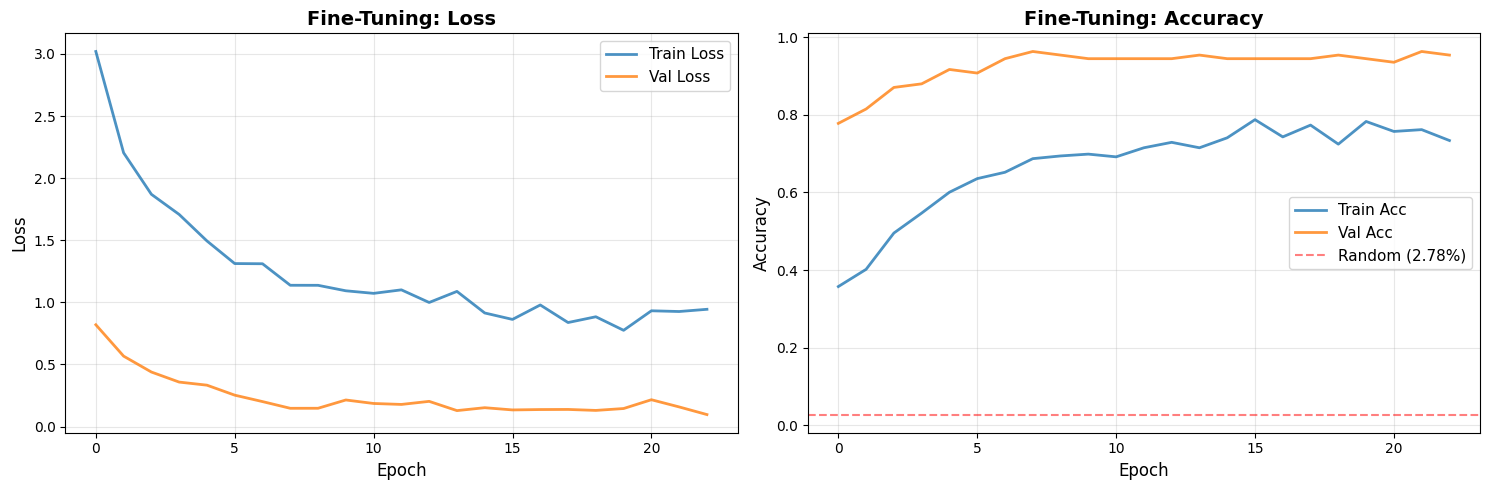

✅ Plot saved as 'finetuning_progress.png'


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Loss plot
axes[0].plot(finetune_train_losses, label='Train Loss', linewidth=2, alpha=0.8)
axes[0].plot(finetune_val_losses, label='Val Loss', linewidth=2, alpha=0.8)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss', fontsize=12)
axes[0].set_title('Fine-Tuning: Loss', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# Accuracy plot
axes[1].plot(finetune_train_accs, label='Train Acc', linewidth=2, alpha=0.8)
axes[1].plot(finetune_val_accs, label='Val Acc', linewidth=2, alpha=0.8)
axes[1].axhline(y=1/36, color='r', linestyle='--', label='Random (2.78%)', alpha=0.5)
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Accuracy', fontsize=12)
axes[1].set_title('Fine-Tuning: Accuracy', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('finetuning_progress.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"✅ Plot saved as 'finetuning_progress.png'")

## Compare: Original vs Fine-Tuned Model

In [13]:
print("\n" + "="*70)
print("MODEL COMPARISON ON FINE-TUNING VALIDATION SET")
print("="*70 + "\n")

# Test original pre-trained model
print("1️⃣  Testing ORIGINAL pre-trained model...")
original_model = CNN(num_classes=36).to(device)
original_model.load_state_dict(torch.load(pretrained_model_path, map_location=device))
original_model.eval()

correct = 0
total = 0
with torch.no_grad():
    for inputs, labels in finetune_val_loader:
        inputs = inputs.to(device)
        labels = torch.squeeze(labels).to(device)
        outputs = original_model(inputs)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

original_acc = correct / total
print(f"   Original Model Accuracy: {original_acc:.4f} ({original_acc*100:.2f}%)")

# Test fine-tuned model
print("\n2️⃣  Testing FINE-TUNED model...")
finetune_model.load_state_dict(torch.load(finetuned_best_path, map_location=device))
finetune_model.eval()

correct = 0
total = 0
with torch.no_grad():
    for inputs, labels in finetune_val_loader:
        inputs = inputs.to(device)
        labels = torch.squeeze(labels).to(device)
        outputs = finetune_model(inputs)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

finetuned_acc = correct / total
print(f"   Fine-tuned Model Accuracy: {finetuned_acc:.4f} ({finetuned_acc*100:.2f}%)")

# Calculate improvement
improvement = finetuned_acc - original_acc
improvement_pct = (improvement / original_acc * 100) if original_acc > 0 else 0

print("\n" + "="*70)
print("RESULTS")
print("="*70)
print(f"Original Model:    {original_acc:.4f} ({original_acc*100:.2f}%)")
print(f"Fine-tuned Model:  {finetuned_acc:.4f} ({finetuned_acc*100:.2f}%)")
print(f"Improvement:       {improvement:+.4f} ({improvement_pct:+.2f}%)")

if improvement > 0:
    print("\n✅ Fine-tuning SUCCESSFUL! Model improved for production dataset.")
elif improvement > -0.02:
    print("\n⚠️  Fine-tuning shows marginal difference. Original model may be sufficient.")
else:
    print("\n❌ Fine-tuning decreased performance. Consider:")
    print("   - Increasing FINETUNE_EPOCHS")
    print("   - Setting FREEZE_EARLY_LAYERS = True")
    print("   - Lowering learning rate further")
    print("   - Adding more data augmentation")

print("="*70 + "\n")


MODEL COMPARISON ON FINE-TUNING VALIDATION SET

1️⃣  Testing ORIGINAL pre-trained model...
   Original Model Accuracy: 0.4259 (42.59%)

2️⃣  Testing FINE-TUNED model...
   Fine-tuned Model Accuracy: 0.9630 (96.30%)

RESULTS
Original Model:    0.4259 (42.59%)
Fine-tuned Model:  0.9630 (96.30%)
Improvement:       +0.5370 (+126.09%)

✅ Fine-tuning SUCCESSFUL! Model improved for production dataset.

